# NER Results Analysis — decicontas.br

This notebook loads all experiment results, computes token-level and span-level metrics, and provides comparative analysis across three experiment groups:

1. **Few-Shot & Supervised** — Main comparison of LLMs (few-shot) vs fine-tuned models
2. **Function Calling vs JSON Schema** — Impact of structured output method on performance
3. **Prompt Engineering** — Comparison of prompting techniques (few-shot, two-stage, dynamic few-shot, self-refinement)

In [1]:
import os
import json
import pickle
import warnings
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import defaultdict
from rapidfuzz import fuzz
from sklearn.metrics import precision_recall_fscore_support

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

EXPERIMENTS_DIR = Path('dataset/experiments/')
FEWSHOT_DIR = EXPERIMENTS_DIR / 'few_shot_and_supervised'
FC_JS_DIR = EXPERIMENTS_DIR / 'function_calling_json_schema'
PROMPT_DIR = EXPERIMENTS_DIR / 'prompt_engineering'

print(f'Few-shot & supervised: {len(list(FEWSHOT_DIR.glob("*")))} files')
print(f'FC vs JSON Schema:    {len(list(FC_JS_DIR.glob("*")))} files')
print(f'Prompt engineering:   {len(list(PROMPT_DIR.glob("*")))} files')

Few-shot & supervised: 14 files
FC vs JSON Schema:    5 files
Prompt engineering:   16 files


---
## Metric Functions

In [2]:
DICT_LABELS = {
    "obrigacoes": "OBRIGACAO",
    "recomendacoes": "RECOMENDACAO",
    "ressarcimentos": "RESSARCIMENTO",
    "multas": "MULTA",
}

ENTITY_LABELS = ['MULTA', 'OBRIGACAO', 'RECOMENDACAO', 'RESSARCIMENTO']

def convert_pred_to_golden_format(row, window_size=500, step_size=100, min_score=80):
    pred_spans = []
    text = row['text']
    pred = row['pred']
    for label_type, spans in pred.items():
        for span in (spans or []):
            if not isinstance(span, dict):
                continue
            span_text = (
                span.get("descricao_multa") or span.get("descricao_obrigacao")
                or span.get("descricao_ressarcimento") or span.get("descricao_recomendacao")
            )
            if not span_text:
                continue
            best_score, best_pos, best_substring = 0, -1, ""
            for start in range(0, len(text), step_size):
                window = text[start:start + window_size]
                score = fuzz.partial_ratio(span_text, window)
                if score > best_score and score >= min_score:
                    best_score = score
                    best_pos = start + window.find(span_text.split()[0]) if span_text.split() else start
                    best_substring = span_text
            if best_score >= min_score and best_pos >= 0:
                pred_spans.append({
                    "start": best_pos, "end": best_pos + len(best_substring),
                    "text": best_substring, "labels": [DICT_LABELS[label_type]]
                })
    return pred_spans


def _strip_bio(tag):
    if tag == 'O' or tag is None:
        return 'O'
    parts = tag.split('-', 1)
    return parts[1] if len(parts) == 2 else parts[0]


def compute_iou_score(span_a, span_b, label_a, label_b, threshold=0.5):
    s_a, e_a = span_a
    s_b, e_b = span_b
    if e_a <= s_b or e_b <= s_a:
        return 0.0
    intersection = max(0, min(e_a, e_b) - max(s_a, s_b))
    union = max(e_a, e_b) - min(s_a, s_b)
    iou = intersection / union if union > 0 else 0.0
    return 1.0 if (iou >= threshold and label_a == label_b) else 0.0


def _extract_spans_from_bio(tags):
    spans, start, label = [], None, None
    for j, tag in enumerate(tags):
        if tag.startswith('B-'):
            if start is not None:
                spans.append((start, j, label))
            label, start = tag[2:], j
        elif tag.startswith('I-') and start is not None and tag[2:] == label:
            continue
        else:
            if start is not None:
                spans.append((start, j, label))
                start, label = None, None
    if start is not None:
        spans.append((start, len(tags), label))
    return spans


def _compute_span_metrics(label_metrics):
    total_gold = sum(v['total_gold'] for v in label_metrics.values())
    total_pred = sum(v['total_pred'] for v in label_metrics.values())
    total_matched = sum(v['matched'] for v in label_metrics.values())
    iou_p = total_matched / total_pred if total_pred else 0
    iou_r = total_matched / total_gold if total_gold else 0
    iou_f1 = (2 * iou_p * iou_r / (iou_p + iou_r)) if (iou_p + iou_r) else 0
    per_label = {}
    for lab, m in label_metrics.items():
        pr = m['matched'] / m['total_pred'] if m['total_pred'] else 0
        rc = m['matched'] / m['total_gold'] if m['total_gold'] else 0
        f1 = (2 * pr * rc / (pr + rc)) if (pr + rc) else 0
        per_label[lab] = {'precision': pr, 'recall': rc, 'f1': f1}
    return iou_p, iou_r, iou_f1, per_label


def _build_metrics_dict(token_prec, token_rec, token_f1, iou_p, iou_r, iou_f1, per_label):
    metrics = {
        'token_precision': float(token_prec), 'token_recall': float(token_rec),
        'token_f1': float(token_f1), 'span_precision': iou_p,
        'span_recall': iou_r, 'span_f1': iou_f1,
    }
    for label, vals in per_label.items():
        metrics[f'f1_{label}'] = vals['f1']
        metrics[f'precision_{label}'] = vals['precision']
        metrics[f'recall_{label}'] = vals['recall']
    return metrics

In [3]:
def calculate_metrics(df, iou_threshold=0.5, spacy_model='pt_core_news_sm'):
    nlp = spacy.load(spacy_model)
    y_true_tokens, y_pred_tokens = [], []
    label_metrics = defaultdict(lambda: {'total_gold': 0, 'total_pred': 0, 'matched': 0})

    for _, row in df.iterrows():
        text = row['text']
        doc = nlp(text)
        true_bio = ['O'] * len(doc)
        pred_bio = ['O'] * len(doc)

        for ann in row.get('golden', []):
            start, end, label = ann['start'], ann['end'], ann['labels'][0]
            cs = doc.char_span(start, end, label=label, alignment_mode='expand')
            if cs:
                for j, tok in enumerate(cs):
                    true_bio[tok.i] = f'B-{label}' if j == 0 else f'I-{label}'

        for ann in row.get('pred_as_golden', []):
            start, end, label = ann['start'], ann['end'], ann['labels'][0]
            cs = doc.char_span(start, end, label=label, alignment_mode='expand')
            if cs:
                for j, tok in enumerate(cs):
                    pred_bio[tok.i] = f'B-{label}' if j == 0 else f'I-{label}'

        y_true_tokens.append([_strip_bio(t) for t in true_bio])
        y_pred_tokens.append([_strip_bio(t) for t in pred_bio])

        gold_spans = [(a['start'], a['end'], a['labels'][0]) for a in row.get('golden', [])]
        pred_spans = [(a['start'], a['end'], a['labels'][0]) for a in row.get('pred_as_golden', [])]
        for _, _, lab in gold_spans: label_metrics[lab]['total_gold'] += 1
        for _, _, lab in pred_spans: label_metrics[lab]['total_pred'] += 1

        matched_pairs = set()
        for pi, p in enumerate(pred_spans):
            for gi, g in enumerate(gold_spans):
                if (pi, gi) in matched_pairs: continue
                if compute_iou_score((p[0], p[1]), (g[0], g[1]), p[2], g[2], threshold=iou_threshold) > 0:
                    label_metrics[p[2]]['matched'] += 1
                    matched_pairs.add((pi, gi))
                    break

    flat_true, flat_pred = [], []
    for t_seq, p_seq in zip(y_true_tokens, y_pred_tokens):
        for t, p in zip(t_seq, p_seq):
            if t != 'O' or p != 'O':
                flat_true.append(t)
                flat_pred.append(p)

    if not flat_true:
        token_prec = token_rec = token_f1 = 0.0
    else:
        labels_sorted = sorted(set(l for l in flat_true + flat_pred if l != 'O'))
        token_prec, token_rec, token_f1, _ = precision_recall_fscore_support(
            flat_true, flat_pred, labels=labels_sorted, average='micro', zero_division=0)

    iou_p, iou_r, iou_f1, per_label = _compute_span_metrics(label_metrics)
    return _build_metrics_dict(token_prec, token_rec, token_f1, iou_p, iou_r, iou_f1, per_label)


def evaluate_llm_results(df_results):
    df_results['pred_as_golden'] = df_results.apply(
        lambda row: convert_pred_to_golden_format(row, window_size=500, step_size=100, min_score=80), axis=1)
    return calculate_metrics(df_results, iou_threshold=0.5)


def evaluate_bio_results(data):
    gold_seqs = data['true_labels']
    pred_seqs = data['pred_labels']

    flat_true, flat_pred = [], []
    label_metrics = defaultdict(lambda: {'total_gold': 0, 'total_pred': 0, 'matched': 0})

    for gold_tags, pred_tags in zip(gold_seqs, pred_seqs):
        min_len = min(len(gold_tags), len(pred_tags))
        gt, pt = gold_tags[:min_len], pred_tags[:min_len]

        for t, p in zip(gt, pt):
            tl, pl = _strip_bio(t), _strip_bio(p)
            if tl != 'O' or pl != 'O':
                flat_true.append(tl)
                flat_pred.append(pl)

        g_spans = _extract_spans_from_bio(gt)
        p_spans = _extract_spans_from_bio(pt)
        for _, _, lab in g_spans: label_metrics[lab]['total_gold'] += 1
        for _, _, lab in p_spans: label_metrics[lab]['total_pred'] += 1
        matched = set()
        for pi, p in enumerate(p_spans):
            for gi, g in enumerate(g_spans):
                if (pi, gi) in matched: continue
                if compute_iou_score((p[0], p[1]), (g[0], g[1]), p[2], g[2], threshold=0.5) > 0:
                    label_metrics[p[2]]['matched'] += 1
                    matched.add((pi, gi))
                    break

    labels_sorted = sorted(set(l for l in flat_true + flat_pred if l != 'O'))
    token_prec, token_rec, token_f1, _ = precision_recall_fscore_support(
        flat_true, flat_pred, labels=labels_sorted, average='micro', zero_division=0)

    iou_p, iou_r, iou_f1, per_label = _compute_span_metrics(label_metrics)
    return _build_metrics_dict(token_prec, token_rec, token_f1, iou_p, iou_r, iou_f1, per_label)


print('Metric functions loaded.')

Metric functions loaded.


---
## Helper: load a directory of results

In [4]:
def load_and_evaluate_directory(directory, convert_pkl_to_json=True):
    """Load all .json and .pkl files from a directory, evaluate metrics.
    
    For .pkl files:
      - If dict with 'true_labels'/'pred_labels' -> BIO supervised format
      - If DataFrame/list -> LLM format, optionally saved as .json
    
    Returns dict of {experiment_name: metrics_dict}
    """
    results = {}
    directory = Path(directory)
    
    # --- Process JSON files ---
    for jf in sorted(directory.glob('*.json')):
        name = jf.stem.replace('models_results_decicontas_', '')
        print(f'  {name} ... ', end='')
        try:
            df = pd.read_json(jf)
            if not {'text', 'pred', 'golden'}.issubset(df.columns):
                print(f'SKIP (missing columns)')
                continue
            metrics = evaluate_llm_results(df.copy())
            results[name] = metrics
            print(f'token_f1={metrics["token_f1"]:.4f}  span_f1={metrics["span_f1"]:.4f}  ({len(df)} docs)')
        except Exception as e:
            print(f'ERROR: {e}')
    
    # --- Process PKL files ---
    for pkl_path in sorted(directory.glob('*.pkl')):
        name = pkl_path.stem
        print(f'  {name} ... ', end='')
        try:
            with open(pkl_path, 'rb') as f:
                data = pickle.load(f)
            
            # BIO supervised format
            if isinstance(data, dict) and 'true_labels' in data and 'pred_labels' in data:
                metrics = evaluate_bio_results(data)
                results[name] = metrics
                print(f'BIO  token_f1={metrics["token_f1"]:.4f}  span_f1={metrics["span_f1"]:.4f}')
                continue
            
            # LLM format (DataFrame or list)
            if isinstance(data, list):
                df = pd.DataFrame(data)
            elif isinstance(data, pd.DataFrame):
                df = data
            else:
                print(f'SKIP (unsupported type {type(data).__name__})')
                continue
            
            if not {'text', 'pred', 'golden'}.issubset(df.columns):
                print(f'SKIP (missing columns)')
                continue
            
            # Convert pkl -> json for future runs
            if convert_pkl_to_json:
                json_name = f'models_results_decicontas_{name}.json'
                json_path = directory / json_name
                if not json_path.exists():
                    df.to_json(json_path, orient='records', force_ascii=False, indent=2)
                    print(f'[saved .json] ', end='')
            
            metrics = evaluate_llm_results(df.copy())
            results[name] = metrics
            print(f'LLM  token_f1={metrics["token_f1"]:.4f}  span_f1={metrics["span_f1"]:.4f}  ({len(df)} docs)')
        except Exception as e:
            print(f'ERROR: {e}')
    
    return results


def results_to_dataframe(results, parse_model_strategy=True):
    """Convert results dict to a sorted DataFrame."""
    df = pd.DataFrame(results).T
    df.index.name = 'experiment'
    
    if parse_model_strategy:
        df['model'] = df.index.map(lambda x: x.rsplit('__', 1)[0] if '__' in x else x)
        df['strategy'] = df.index.map(lambda x: x.rsplit('__', 1)[1] if '__' in x else 'few_shot')
    
    main_cols = ['model', 'strategy'] if parse_model_strategy else []
    metric_cols = ['token_f1', 'token_precision', 'token_recall',
                   'span_f1', 'span_precision', 'span_recall']
    entity_cols = [c for c in df.columns if c.startswith(('f1_', 'precision_', 'recall_')) and c not in metric_cols]
    ordered = main_cols + [c for c in metric_cols if c in df.columns] + sorted(entity_cols)
    remaining = [c for c in df.columns if c not in ordered]
    df = df[ordered + remaining]
    
    return df.sort_values('span_f1', ascending=False)


print('Helpers loaded.')

Helpers loaded.


---
# Experiment 1: Few-Shot & Supervised

Main comparison between LLMs with few-shot prompting and fine-tuned supervised models (BERT, BiLSTM-CRF).

In [5]:
print(f'Loading from {FEWSHOT_DIR}\n')
results_fewshot = load_and_evaluate_directory(FEWSHOT_DIR)

Loading from dataset/experiments/few_shot_and_supervised

  deepseek-v3_few_shot ... token_f1=0.7314  span_f1=0.6737  (866 docs)
  gemini-2.5-flash_few_shot ... token_f1=0.7533  span_f1=0.7134  (866 docs)
  gpt-35 ... token_f1=0.7758  span_f1=0.7171  (1425 docs)
  gpt-4-turbo ... token_f1=0.8011  span_f1=0.7524  (1425 docs)
  gpt-41-mini ... token_f1=0.7821  span_f1=0.7399  (1425 docs)
  gpt-41-nano ... token_f1=0.5596  span_f1=0.4365  (1425 docs)
  gpt-41 ... token_f1=0.7841  span_f1=0.7174  (1425 docs)
  gpt-4o ... token_f1=0.7891  span_f1=0.7381  (1425 docs)
  gpt-5.4-mini_few_shot ... token_f1=0.7879  span_f1=0.7640  (866 docs)
  gpt-5.4-nano_few_shot ... token_f1=0.7820  span_f1=0.7574  (866 docs)
  bilstm-crf__supervised ... BIO  token_f1=0.8001  span_f1=0.6440
  neuralmind_bert-base-portuguese-cased__supervised ... BIO  token_f1=0.8658  span_f1=0.7405
  neuralmind_bert-large-portuguese-cased__supervised ... BIO  token_f1=0.8652  span_f1=0.7179
  rufimelo_Legal-BERTimbau-base__su

In [6]:
df_fewshot = results_to_dataframe(results_fewshot)

# Tag paradigm
df_fewshot['paradigm'] = df_fewshot['strategy'].apply(
    lambda s: 'supervised' if s == 'supervised' else 'few-shot')

display(df_fewshot.style.format(
    '{:.4f}', subset=[c for c in df_fewshot.columns if c not in ['model', 'strategy', 'paradigm']]
).background_gradient(cmap='YlGn', subset=['token_f1', 'span_f1']))

,model,strategy,token_f1,token_precision,token_recall,span_f1,span_precision,span_recall,f1_MULTA,f1_OBRIGACAO,f1_RECOMENDACAO,f1_RESSARCIMENTO,precision_MULTA,precision_OBRIGACAO,precision_RECOMENDACAO,precision_RESSARCIMENTO,recall_MULTA,recall_OBRIGACAO,recall_RECOMENDACAO,recall_RESSARCIMENTO,paradigm
experiment,,,,,,,,,,,,,,,,,,,,,
gpt-5.4-mini_few_shot,gpt-5.4-mini_few_shot,few_shot,0.7879,0.8028,0.7735,0.7640,0.7002,0.8405,0.8694,0.6616,0.7413,0.6619,0.8356,0.6042,0.6092,0.5974,0.9059,0.7311,0.9464,0.7419,few-shot
gpt-5.4-nano_few_shot,gpt-5.4-nano_few_shot,few_shot,0.7820,0.8006,0.7643,0.7574,0.6877,0.8428,0.8387,0.6743,0.7133,0.7050,0.7845,0.6197,0.5862,0.6364,0.9010,0.7395,0.9107,0.7903,few-shot
gpt-4-turbo,gpt-4-turbo,few_shot,0.8011,0.7990,0.8033,0.7524,0.6644,0.8674,0.8670,0.6007,0.7297,0.7482,0.8147,0.4973,0.6000,0.6842,0.9265,0.7583,0.9310,0.8254,few-shot
rufimelo_Legal-BERTimbau-base__supervised,rufimelo_Legal-BERTimbau-base,supervised,0.8507,0.8435,0.8579,0.7440,0.8017,0.6940,0.7919,0.7027,0.6733,0.7288,0.8354,0.8333,0.6939,0.7544,0.7527,0.6075,0.6538,0.7049,supervised
neuralmind_bert-base-portuguese-cased__supervised,neuralmind_bert-base-portuguese-cased,supervised,0.8658,0.8569,0.8749,0.7405,0.7781,0.7065,0.7933,0.6947,0.6863,0.7009,0.8068,0.7952,0.7000,0.7321,0.7802,0.6168,0.6731,0.6721,supervised
gpt-41-mini,gpt-41-mini,few_shot,0.7821,0.7774,0.7868,0.7399,0.6608,0.8404,0.8256,0.6406,0.6933,0.7087,0.7510,0.5590,0.5652,0.7031,0.9167,0.7500,0.8966,0.7143,few-shot
gpt-4o,gpt-4o,few_shot,0.7891,0.7934,0.7847,0.7381,0.6512,0.8517,0.8630,0.5705,0.7483,0.6944,0.8077,0.4775,0.6180,0.6173,0.9265,0.7083,0.9483,0.7937,few-shot
neuralmind_bert-large-portuguese-cased__supervised,neuralmind_bert-large-portuguese-cased,supervised,0.8652,0.8609,0.8695,0.7179,0.7407,0.6965,0.7738,0.7113,0.5102,0.7273,0.7676,0.7931,0.5435,0.7333,0.7802,0.6449,0.4808,0.7213,supervised
gpt-41,gpt-41,few_shot,0.7841,0.7598,0.8101,0.7174,0.6221,0.8472,0.8276,0.5926,0.6415,0.7519,0.7792,0.4706,0.5050,0.7143,0.8824,0.8000,0.8793,0.7937,few-shot


### 1.1 Overall Comparison — Token F1 vs Span F1

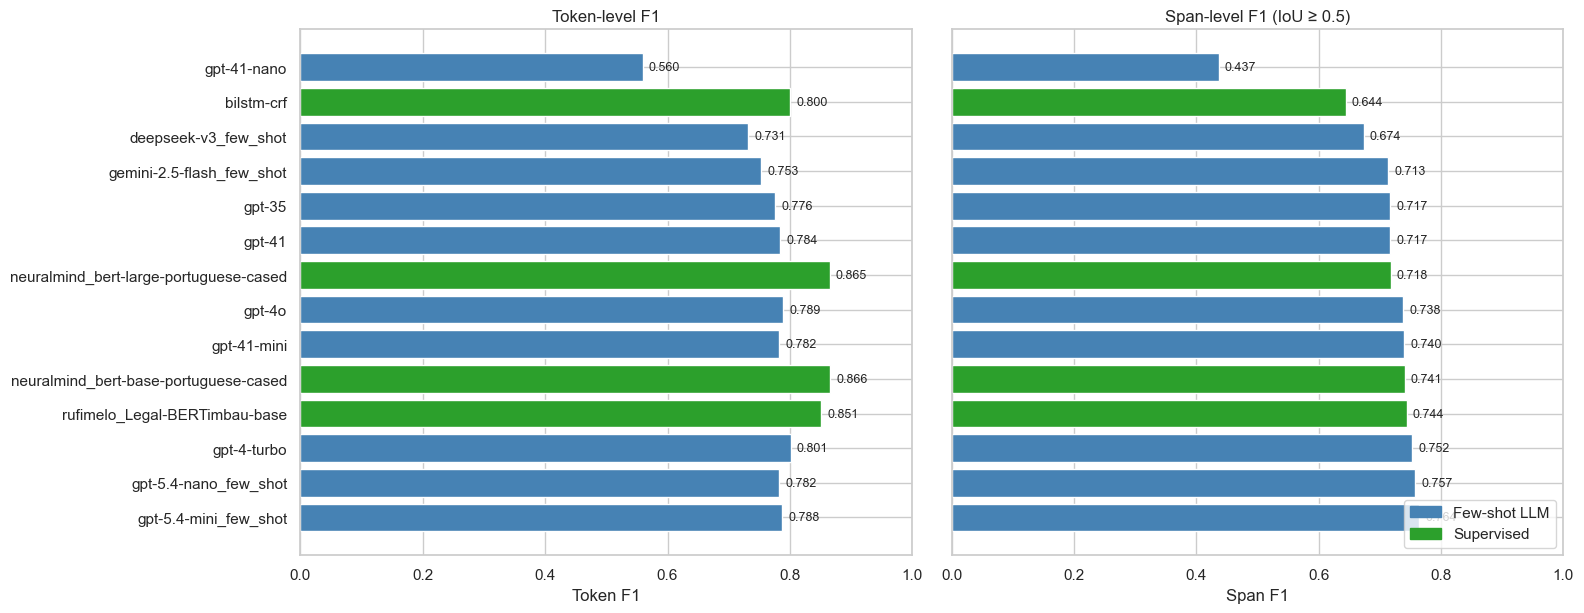

In [7]:
df_plot = df_fewshot.copy()
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(df_plot) * 0.45)), sharey=True)

colors = df_plot['paradigm'].map({'supervised': '#2ca02c', 'few-shot': 'steelblue'}).values

axes[0].barh(df_plot['model'], df_plot['token_f1'], color=colors)
axes[0].set_xlabel('Token F1')
axes[0].set_title('Token-level F1')
axes[0].set_xlim(0, 1)
for i, v in enumerate(df_plot['token_f1']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

axes[1].barh(df_plot['model'], df_plot['span_f1'], color=colors)
axes[1].set_xlabel('Span F1')
axes[1].set_title('Span-level F1 (IoU ≥ 0.5)')
axes[1].set_xlim(0, 1)
for i, v in enumerate(df_plot['span_f1']):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='steelblue', label='Few-shot LLM'),
    Patch(color='#2ca02c', label='Supervised'),
], loc='lower right')

plt.tight_layout()
plt.savefig('exp1_overall_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 Per-Entity Span F1 Heatmap

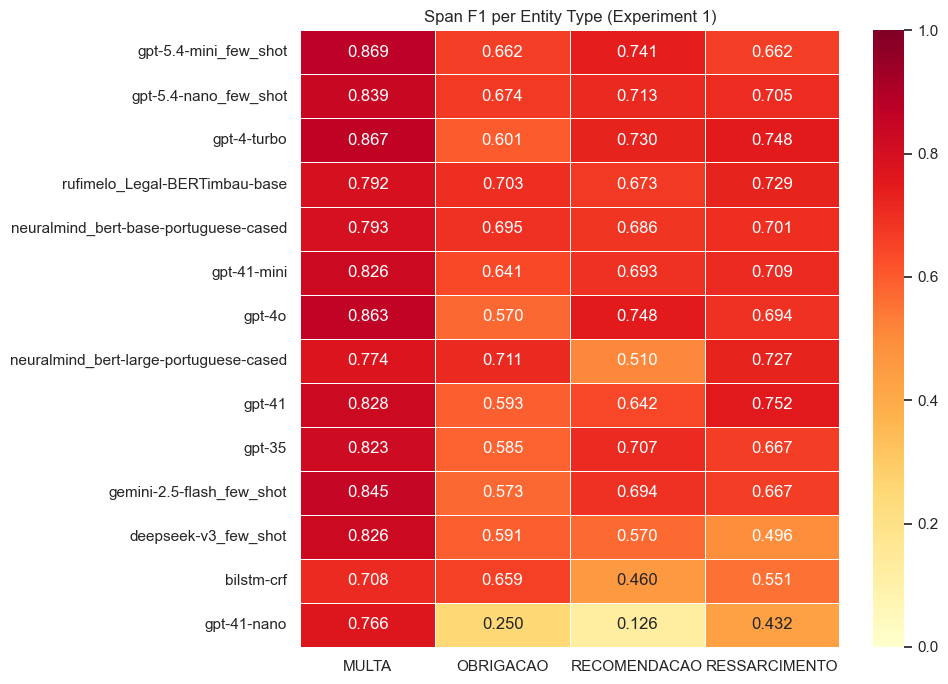

In [8]:
f1_cols = [f'f1_{l}' for l in ENTITY_LABELS if f'f1_{l}' in df_fewshot.columns]
df_entity = df_fewshot[f1_cols].copy()
df_entity.columns = [c.replace('f1_', '') for c in df_entity.columns]
df_entity.index = df_fewshot['model']

fig, ax = plt.subplots(figsize=(10, max(5, len(df_entity) * 0.5)))
sns.heatmap(df_entity, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, vmin=0, vmax=1)
ax.set_title('Span F1 per Entity Type (Experiment 1)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('exp1_entity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 Precision vs Recall Scatter

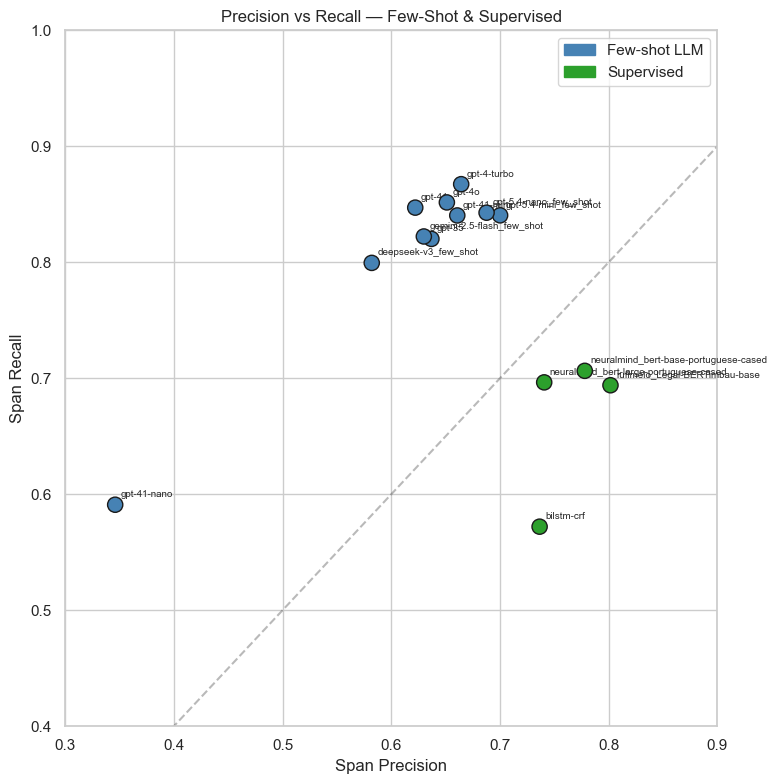

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

paradigm_colors = df_fewshot['paradigm'].map({'supervised': '#2ca02c', 'few-shot': 'steelblue'})
ax.scatter(df_fewshot['span_precision'], df_fewshot['span_recall'],
           s=120, c=paradigm_colors, edgecolors='k', zorder=5)

for _, row in df_fewshot.iterrows():
    ax.annotate(row['model'], (row['span_precision'], row['span_recall']),
                fontsize=7, ha='left', va='bottom', xytext=(4, 4),
                textcoords='offset points')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Span Precision')
ax.set_ylabel('Span Recall')
ax.set_title('Precision vs Recall — Few-Shot & Supervised')
ax.set_xlim(0.3, 0.9)
ax.set_ylim(0.4, 1.0)
ax.legend(handles=[
    Patch(color='steelblue', label='Few-shot LLM'),
    Patch(color='#2ca02c', label='Supervised'),
])
plt.tight_layout()
plt.savefig('exp1_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Supervised vs LLM Summary

In [10]:
paradigm_summary = df_fewshot.groupby('paradigm')[['token_f1', 'span_f1']].agg(['mean', 'std', 'max'])
paradigm_summary.columns = ['_'.join(c) for c in paradigm_summary.columns]
display(paradigm_summary.round(4))

,token_f1_mean,token_f1_std,token_f1_max,span_f1_mean,span_f1_std,span_f1_max
paradigm,,,,,,
few-shot,0.7546,0.0714,0.8011,0.7010,0.0966,0.764
supervised,0.8454,0.0310,0.8658,0.7116,0.0465,0.744


---
# Experiment 2: Function Calling vs JSON Schema

Impact of the `with_structured_output` method on the same models.
The `few_shot_and_supervised/` results used `function_calling`; the `function_calling_json_schema/` results used the default (json_schema).

In [11]:
print(f'Loading from {FC_JS_DIR}\n')
results_fcjs = load_and_evaluate_directory(FC_JS_DIR, convert_pkl_to_json=False)

Loading from dataset/experiments/function_calling_json_schema

  gpt-3.5-turbo_few_shot_json ... token_f1=0.7332  span_f1=0.6852  (866 docs)
  gpt-4o_few_shot_json ... token_f1=0.7362  span_f1=0.6836  (866 docs)
  gpt-5.4-mini_few_shot_json ... token_f1=0.5807  span_f1=0.5769  (866 docs)
  gpt-5.4-nano_few_shot_json ... token_f1=0.7479  span_f1=0.7194  (866 docs)
  gpt-5.4_few_shot_json ... token_f1=0.7526  span_f1=0.7107  (866 docs)


In [ ]:
df_fcjs = results_to_dataframe(results_fcjs, parse_model_strategy=False)

# Clean model names: strip _json suffix for pairing
df_fcjs['model_clean'] = df_fcjs.index.map(
    lambda x: x.replace('_json', '').replace('_few_shot', ''))
df_fcjs['method'] = 'json_schema'

# Build function_calling counterparts from experiment 1
fc_models = {}
for name, metrics in results_fewshot.items():
    clean = name.replace('__supervised', '').replace('__few_shot', '')
    if clean in df_fcjs['model_clean'].values:
        fc_models[clean] = metrics

df_fc = pd.DataFrame(fc_models).T
df_fc['model_clean'] = df_fc.index
df_fc['method'] = 'function_calling'

# Combine
df_method_cmp = pd.concat([df_fc, df_fcjs], ignore_index=True)
df_method_cmp = df_method_cmp.sort_values(['model_clean', 'method'])

display(df_method_cmp[['model_clean', 'method', 'token_f1', 'span_f1',
                        'span_precision', 'span_recall']].round(4))

,model_clean,method,token_f1,span_f1,span_precision,span_recall
3,gpt-3.5-turbo,json_schema,0.7332,0.6852,0.6264,0.7563
0,gpt-4o,function_calling,0.7891,0.7381,0.6512,0.8517
4,gpt-4o,json_schema,0.7362,0.6836,0.6383,0.7358
2,gpt-5.4,json_schema,0.7526,0.7107,0.6583,0.7722
5,gpt-5.4-mini,json_schema,0.5807,0.5769,0.6598,0.5125
1,gpt-5.4-nano,json_schema,0.7479,0.7194,0.6699,0.7768


### 2.1 Method Impact — Grouped Bar Chart

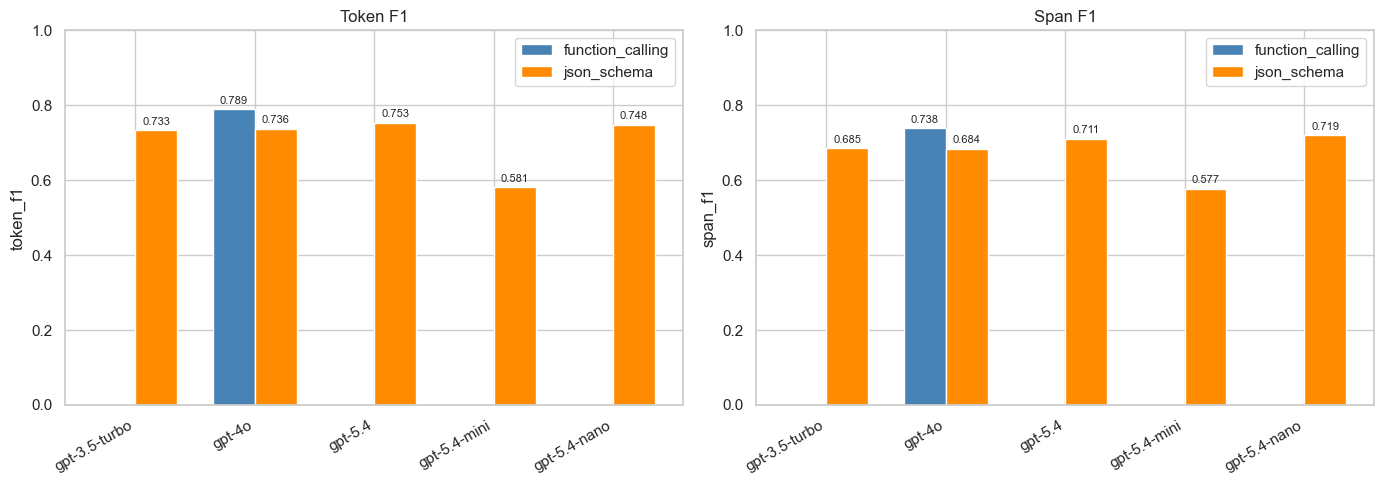

In [13]:
models = sorted(df_method_cmp['model_clean'].unique())
x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in [(axes[0], 'token_f1', 'Token F1'), (axes[1], 'span_f1', 'Span F1')]:
    fc_vals = [df_method_cmp[(df_method_cmp['model_clean'] == m) & (df_method_cmp['method'] == 'function_calling')][metric].values
              for m in models]
    js_vals = [df_method_cmp[(df_method_cmp['model_clean'] == m) & (df_method_cmp['method'] == 'json_schema')][metric].values
              for m in models]
    fc_vals = [v[0] if len(v) > 0 else 0 for v in fc_vals]
    js_vals = [v[0] if len(v) > 0 else 0 for v in js_vals]

    bars1 = ax.bar(x - width/2, fc_vals, width, label='function_calling', color='steelblue')
    bars2 = ax.bar(x + width/2, js_vals, width, label='json_schema', color='darkorange')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 1)

    for bars in [bars1, bars2]:
        for bar in bars:
            if bar.get_height() > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('exp2_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Delta per Entity

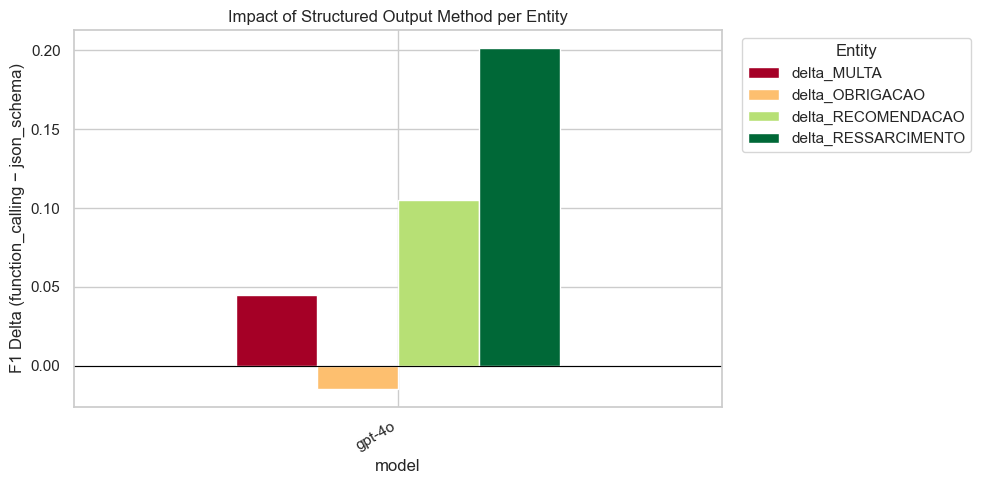

In [14]:
delta_rows = []
for model in models:
    fc_row = df_method_cmp[(df_method_cmp['model_clean'] == model) & (df_method_cmp['method'] == 'function_calling')]
    js_row = df_method_cmp[(df_method_cmp['model_clean'] == model) & (df_method_cmp['method'] == 'json_schema')]
    if len(fc_row) == 0 or len(js_row) == 0:
        continue
    row = {'model': model}
    for label in ENTITY_LABELS:
        col = f'f1_{label}'
        if col in fc_row.columns and col in js_row.columns:
            fc_val = fc_row[col].values[0] if pd.notna(fc_row[col].values[0]) else 0
            js_val = js_row[col].values[0] if pd.notna(js_row[col].values[0]) else 0
            row[f'delta_{label}'] = fc_val - js_val
    delta_rows.append(row)

df_delta = pd.DataFrame(delta_rows).set_index('model')

fig, ax = plt.subplots(figsize=(10, 5))
df_delta.plot(kind='bar', ax=ax, colormap='RdYlGn')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('F1 Delta (function_calling − json_schema)')
ax.set_title('Impact of Structured Output Method per Entity')
ax.legend(title='Entity', bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('exp2_delta_per_entity.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Experiment 3: Prompt Engineering Techniques

Comparison of prompting strategies: few-shot, two-stage, dynamic few-shot, and self-refinement.

In [15]:
print(f'Loading from {PROMPT_DIR}\n')
results_prompt = load_and_evaluate_directory(PROMPT_DIR, convert_pkl_to_json=False)

Loading from dataset/experiments/prompt_engineering

  deepseek-v3_dynamic_few_shot ... token_f1=0.6758  span_f1=0.5663  (866 docs)
  deepseek-v3_few_shot ... token_f1=0.7314  span_f1=0.6737  (866 docs)
  deepseek-v3_self_refinement ... token_f1=0.5589  span_f1=0.3402  (866 docs)
  deepseek-v3_two_stage ... token_f1=0.7589  span_f1=0.6992  (866 docs)
  gemini-2.5-flash_dynamic_few_shot ... token_f1=0.7719  span_f1=0.7106  (866 docs)
  gemini-2.5-flash_few_shot ... token_f1=0.7533  span_f1=0.7134  (866 docs)
  gemini-2.5-flash_self_refinement ... token_f1=0.5836  span_f1=0.3912  (866 docs)
  gemini-2.5-flash_two_stage ... token_f1=0.7708  span_f1=0.7318  (866 docs)
  gpt-5.4-mini_dynamic_few_shot ... token_f1=0.7443  span_f1=0.6837  (866 docs)
  gpt-5.4-mini_few_shot ... token_f1=0.7879  span_f1=0.7640  (866 docs)
  gpt-5.4-mini_self_refinement ... token_f1=0.5698  span_f1=0.3825  (866 docs)
  gpt-5.4-mini_two_stage ... token_f1=0.7349  span_f1=0.6837  (866 docs)
  gpt-5.4-nano_dynamic_

In [16]:
df_prompt = results_to_dataframe(results_prompt, parse_model_strategy=False)

# Parse model and technique from filename
techniques = ['dynamic_few_shot', 'self_refinement', 'two_stage', 'few_shot']

def parse_technique(name):
    for tech in techniques:
        if name.endswith(f'_{tech}'):
            model = name[:-(len(tech) + 1)]
            return model, tech
    return name, 'unknown'

parsed = df_prompt.index.map(parse_technique)
df_prompt['model'] = [p[0] for p in parsed]
df_prompt['technique'] = [p[1] for p in parsed]

display(df_prompt[['model', 'technique', 'token_f1', 'span_f1',
                    'span_precision', 'span_recall']].style.format(
    '{:.4f}', subset=['token_f1', 'span_f1', 'span_precision', 'span_recall']
).background_gradient(cmap='YlGn', subset=['span_f1']))

,model,technique,token_f1,span_f1,span_precision,span_recall
experiment,,,,,,
gpt-5.4-mini_few_shot,gpt-5.4-mini,few_shot,0.7879,0.7640,0.7002,0.8405
gpt-5.4-nano_few_shot,gpt-5.4-nano,few_shot,0.7820,0.7574,0.6877,0.8428
gemini-2.5-flash_two_stage,gemini-2.5-flash,two_stage,0.7708,0.7318,0.6507,0.8360
gpt-5.4-nano_two_stage,gpt-5.4-nano,two_stage,0.7545,0.7242,0.6732,0.7836
gemini-2.5-flash_few_shot,gemini-2.5-flash,few_shot,0.7533,0.7134,0.6300,0.8223
gemini-2.5-flash_dynamic_few_shot,gemini-2.5-flash,dynamic_few_shot,0.7719,0.7106,0.6256,0.8223
gpt-5.4-nano_dynamic_few_shot,gpt-5.4-nano,dynamic_few_shot,0.7376,0.7028,0.6481,0.7677
deepseek-v3_two_stage,deepseek-v3,two_stage,0.7589,0.6992,0.6120,0.8155
gpt-5.4-mini_dynamic_few_shot,gpt-5.4-mini,dynamic_few_shot,0.7443,0.6837,0.6208,0.7608


### 3.1 Technique Comparison — Span F1 by Model × Technique

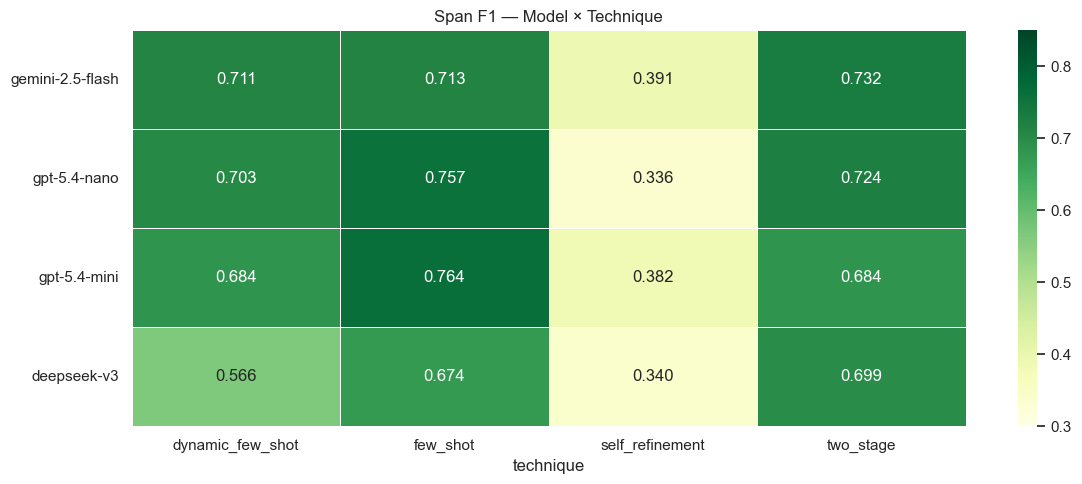

In [17]:
pivot = df_prompt.pivot_table(index='model', columns='technique', values='span_f1')
pivot = pivot.sort_values(pivot.columns.tolist(), ascending=False)

fig, ax = plt.subplots(figsize=(12, max(5, len(pivot) * 0.6)))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', ax=ax,
            linewidths=0.5, vmin=0.3, vmax=0.85)
ax.set_title('Span F1 — Model × Technique')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('exp3_technique_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Strategy Summary — Mean and Std

In [18]:
strategy_summary = df_prompt.groupby('technique')[['token_f1', 'span_f1']].agg(['mean', 'std', 'max'])
strategy_summary.columns = ['_'.join(c) for c in strategy_summary.columns]
strategy_summary = strategy_summary.sort_values('span_f1_mean', ascending=False)
display(strategy_summary.round(4))

,token_f1_mean,token_f1_std,token_f1_max,span_f1_mean,span_f1_std,span_f1_max
technique,,,,,,
few_shot,0.7636,0.0263,0.7879,0.7271,0.0421,0.7640
two_stage,0.7548,0.0149,0.7708,0.7097,0.0223,0.7318
dynamic_few_shot,0.7324,0.0405,0.7719,0.6659,0.0674,0.7106
self_refinement,0.5587,0.0261,0.5836,0.3625,0.0284,0.3912


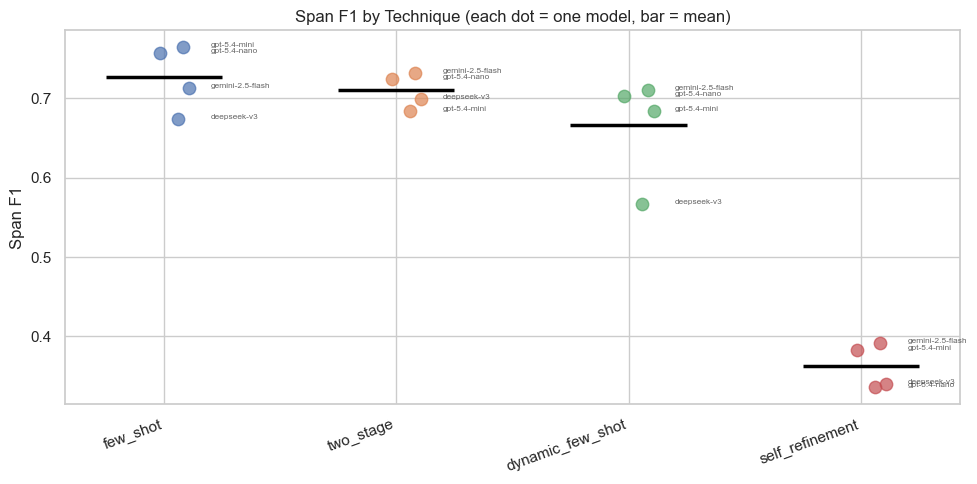

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
tech_order = strategy_summary.index.tolist()

for i, tech in enumerate(tech_order):
    subset = df_prompt[df_prompt['technique'] == tech]
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(subset))
    ax.scatter([i] * len(subset) + jitter, subset['span_f1'], s=80, zorder=5, alpha=0.7)
    ax.hlines(subset['span_f1'].mean(), i - 0.25, i + 0.25, colors='black', linewidth=2.5)

    for _, row in subset.iterrows():
        ax.annotate(row['model'], (i + 0.2, row['span_f1']),
                    fontsize=6, alpha=0.7)

ax.set_xticks(range(len(tech_order)))
ax.set_xticklabels(tech_order, rotation=20, ha='right')
ax.set_ylabel('Span F1')
ax.set_title('Span F1 by Technique (each dot = one model, bar = mean)')
plt.tight_layout()
plt.savefig('exp3_strategy_dots.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Per-Entity Breakdown by Technique (best model per technique)

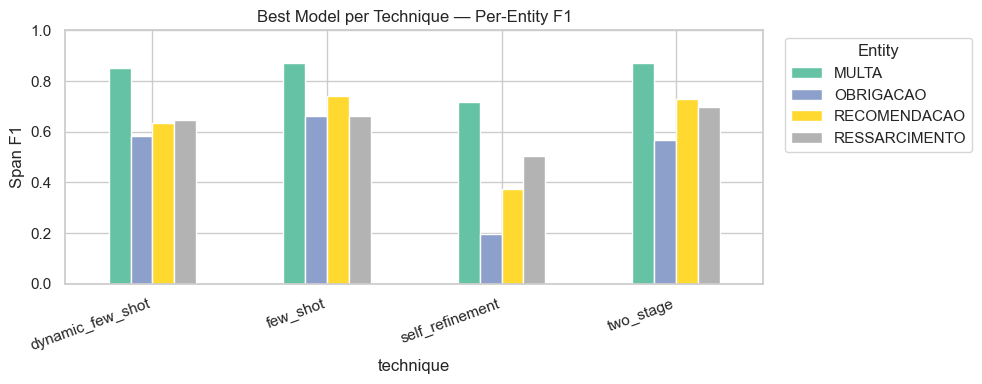

In [20]:
best_per_tech = df_prompt.loc[df_prompt.groupby('technique')['span_f1'].idxmax()]

f1_cols = [f'f1_{l}' for l in ENTITY_LABELS if f'f1_{l}' in best_per_tech.columns]
df_best_entity = best_per_tech.set_index('technique')[f1_cols]
df_best_entity.columns = [c.replace('f1_', '') for c in df_best_entity.columns]

fig, ax = plt.subplots(figsize=(10, 4))
df_best_entity.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_ylabel('Span F1')
ax.set_title('Best Model per Technique — Per-Entity F1')
ax.legend(title='Entity', bbox_to_anchor=(1.02, 1))
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('exp3_best_per_technique_entity.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Global Summary

Top results across all experiments and key insights.

In [21]:
print('=== TOP 5 — Few-Shot & Supervised (Experiment 1) ===')
display(df_fewshot[['model', 'strategy', 'span_f1', 'token_f1']].head())

print('\n=== BEST per Entity (Experiment 1) ===')
for label in ENTITY_LABELS:
    col = f'f1_{label}'
    if col in df_fewshot.columns:
        best_idx = df_fewshot[col].idxmax()
        print(f'  {label}: {df_fewshot.loc[best_idx, "model"]}  '
              f'({df_fewshot.loc[best_idx, col]:.4f})')

print('\n=== TOP 5 — Prompt Engineering (Experiment 3) ===')
display(df_prompt[['model', 'technique', 'span_f1', 'token_f1']].head())

=== TOP 5 — Few-Shot & Supervised (Experiment 1) ===


,model,strategy,span_f1,token_f1
experiment,,,,
gpt-5.4-mini_few_shot,gpt-5.4-mini_few_shot,few_shot,0.763975,0.787871
gpt-5.4-nano_few_shot,gpt-5.4-nano_few_shot,few_shot,0.757421,0.782034
gpt-4-turbo,gpt-4-turbo,few_shot,0.752437,0.801142
rufimelo_Legal-BERTimbau-base__supervised,rufimelo_Legal-BERTimbau-base,supervised,0.744000,0.850670
neuralmind_bert-base-portuguese-cased__supervised,neuralmind_bert-base-portuguese-cased,supervised,0.740548,0.865798



=== BEST per Entity (Experiment 1) ===
  MULTA: gpt-5.4-mini_few_shot  (0.8694)
  OBRIGACAO: neuralmind_bert-large-portuguese-cased  (0.7113)
  RECOMENDACAO: gpt-4o  (0.7483)
  RESSARCIMENTO: gpt-41  (0.7519)

=== TOP 5 — Prompt Engineering (Experiment 3) ===


,model,technique,span_f1,token_f1
experiment,,,,
gpt-5.4-mini_few_shot,gpt-5.4-mini,few_shot,0.763975,0.787871
gpt-5.4-nano_few_shot,gpt-5.4-nano,few_shot,0.757421,0.782034
gemini-2.5-flash_two_stage,gemini-2.5-flash,two_stage,0.731805,0.770809
gpt-5.4-nano_two_stage,gpt-5.4-nano,two_stage,0.724211,0.754475
gemini-2.5-flash_few_shot,gemini-2.5-flash,few_shot,0.713439,0.753329


---
## Export

In [22]:
df_fewshot.to_excel('exp1_fewshot_supervised_summary.xlsx', index=False)
df_prompt.to_excel('exp3_prompt_engineering_summary.xlsx', index=False)

if len(df_method_cmp) > 0:
    df_method_cmp.to_excel('exp2_method_comparison_summary.xlsx', index=False)

print('Exported:')
print('  exp1_fewshot_supervised_summary.xlsx')
print('  exp2_method_comparison_summary.xlsx')
print('  exp3_prompt_engineering_summary.xlsx')

Exported:
  exp1_fewshot_supervised_summary.xlsx
  exp2_method_comparison_summary.xlsx
  exp3_prompt_engineering_summary.xlsx
